In [1]:
import scanpy as sc
sc.settings.verbosity = 1

# Load the clustered object from Stage 2
adata = sc.read_h5ad("data/processed/02_clustered.h5ad")

# Use our chosen resolution (0.5)
adata.obs["leiden"] = adata.obs["leiden_0.5"]
print("Clusters:", adata.obs["leiden"].nunique())

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Clusters: 13


In [2]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", use_raw=True)
print("Done — markers ranked for all 13 clusters.")

Done — markers ranked for all 13 clusters.


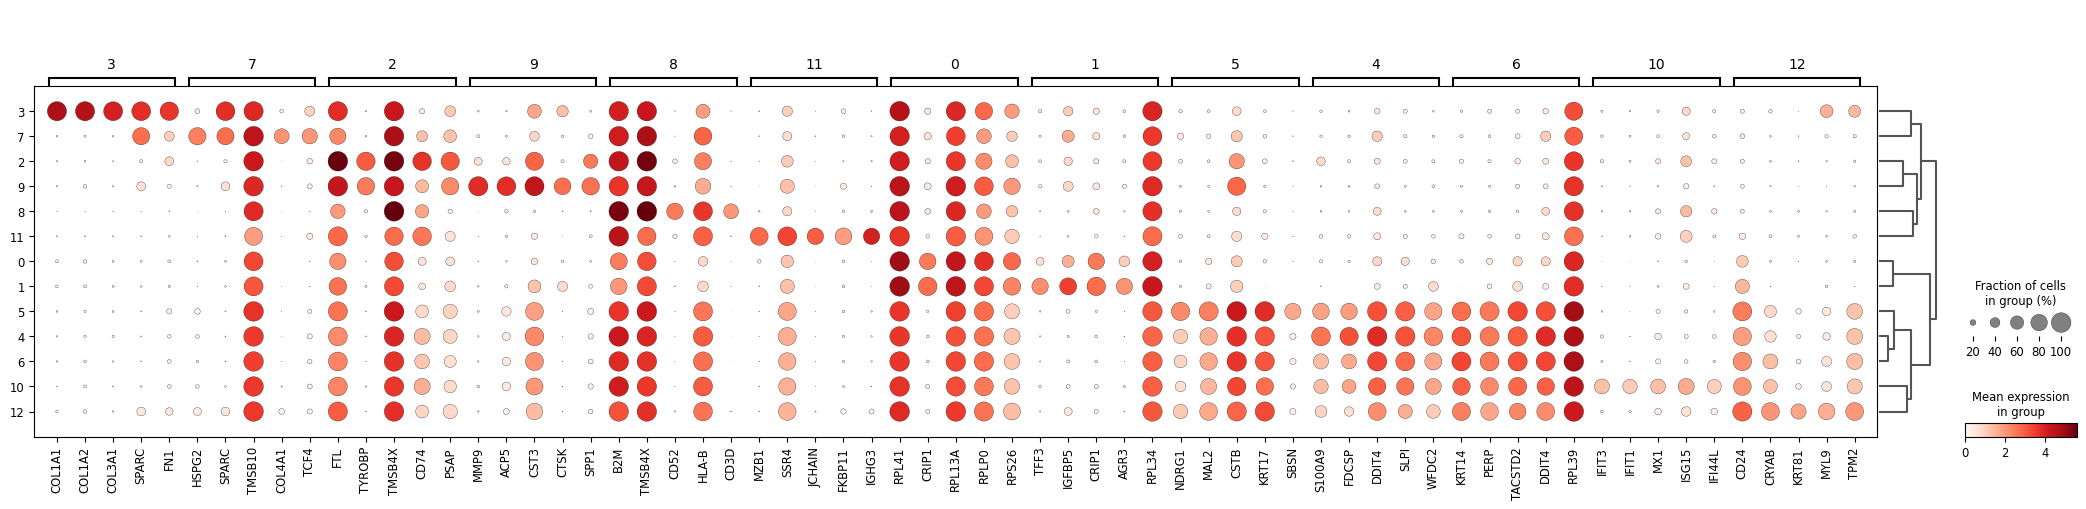

In [3]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

In [ ]:
# ─── Cluster annotation: marker-based identity (res 0.5, 13 clusters) ───
#
# Method: read top markers per cluster, match to known cell-type signatures,
# sanity-check against "does this fit breast tumor tissue?"
#
# STROMAL / IMMUNE:
#   3  → Fibroblasts        COL1A1, COL1A2, COL3A1, SPARC, FN1   (collagen = connective tissue)
#   7  → Endothelial (?)    needs check for PECAM1/VWF/CLDN5     (vessel lining)
#   8  → T cells            CD3D, CD52, B2M                       (CD3D = textbook T marker)
#   9  → T / NK (?)         check NKG7/GNLY for NK                (lymphoid)
#   11 → Plasma / B cells   MZB1, JCHAIN, IGHG3, IGKC             (immunoglobulins = antibodies)
#   2  → Immune (?)         TMSB4X, B2M, HLA — broad, needs check
#
# EPITHELIAL / TUMOR (KRT*, EPCAM = epithelial; malignant cells are epithelial):
#   0, 1, 4, 5, 6, 10, 12  → epithelial/tumor compartment
#       Subtype split via bulk markers:
#         ER+  : GATA3, FOXA1, ESR1
#         TNBC : FOXC1, KRT14, KRT5, EGFR

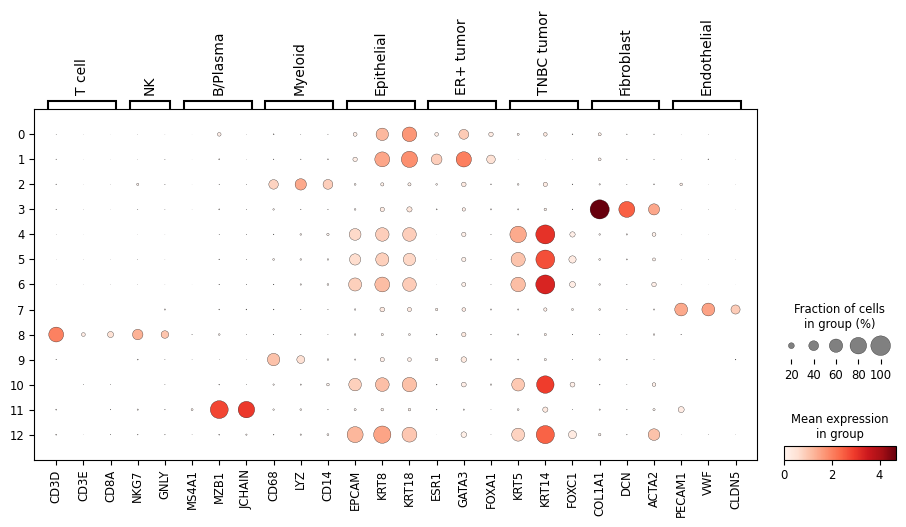

In [4]:
# Confirm identities with known cell-type markers
markers = {
    "T cell": ["CD3D", "CD3E", "CD8A"],
    "NK": ["NKG7", "GNLY"],
    "B/Plasma": ["MS4A1", "MZB1", "JCHAIN"],
    "Myeloid": ["CD68", "LYZ", "CD14"],
    "Epithelial": ["EPCAM", "KRT8", "KRT18"],
    "ER+ tumor": ["ESR1", "GATA3", "FOXA1"],
    "TNBC tumor": ["KRT5", "KRT14", "FOXC1"],
    "Fibroblast": ["COL1A1", "DCN", "ACTA2"],
    "Endothelial": ["PECAM1", "VWF", "CLDN5"],
}
sc.pl.dotplot(adata, markers, groupby="leiden", use_raw=True)

In [ ]:
# Confirmed cluster annotation (res 0.5) — via curated known markers ───
#
# Read from the marker dotplot: each cluster matched to the marker-group it lights up under.
# This CONFIRMED most calls and corrected two provisional ones (clusters 2 & 9).
#
# STROMAL / IMMUNE:
#   3  → Fibroblasts     COL1A1, DCN, ACTA2        (confirmed)
#   7  → Endothelial     PECAM1, VWF, CLDN5        (confirmed)
#   8  → T cells         CD3D                      (confirmed)
#   2  → Myeloid         CD68, LYZ                 (was "immune?" → corrected)
#   9  → Myeloid         CD68, LYZ                 (was "NK?" → corrected to macrophage)
#   11 → Plasma cells    MZB1, JCHAIN             (confirmed)
#
# EPITHELIAL / TUMOR (all light up under EPCAM, KRT8, KRT18):
#   0, 1          → ER+ tumor epithelial    strong ESR1, GATA3, FOXA1
#   4, 5, 6, 10, 12 → TNBC tumor epithelial   strong KRT14, weak ESR1/GATA3
#
# KEY LESSON: trusting the auto top-5 plot would have mislabeled 2 & 9.
# Plotting SPECIFIC known markers is what turned guesses into confirmed calls.
# Subtype split (ER+ vs TNBC) rests directly on the bulk-project markers:
#   ER+  = ESR1/GATA3/FOXA1   |   TNBC = KRT5/KRT14/FOXC1

In [5]:
cluster_to_celltype = {
    "0": "ER+ tumor", "1": "ER+ tumor",
    "4": "TNBC tumor", "5": "TNBC tumor", "6": "TNBC tumor",
    "10": "TNBC tumor", "12": "TNBC tumor",
    "3": "Fibroblast", "7": "Endothelial",
    "8": "T cell", "2": "Myeloid", "9": "Myeloid",
    "11": "Plasma cell",
}
adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_celltype)

# Loud safety check — fail if any cluster went unmapped
assert adata.obs["cell_type"].notna().all(), "A cluster was left unmapped!"
print(adata.obs["cell_type"].value_counts())

cell_type
TNBC tumor     14851
ER+ tumor       9303
Myeloid         3602
T cell          1623
Fibroblast      1444
Plasma cell      314
Endothelial      128
Name: count, dtype: int64


In [ ]:
#Tumor epithelial dominates --> 14,851 
#TNBC+ --> 9,303 
#ER+ --> ~24k of 31k cells. 
#Expected: malignant cells should be the majority.
#Myeloid 3,602, T cells 1,623 — a real immune infiltrate, which is biologically meaningful (immune presence in the TME is exactly what people study).
#Endothelial only 128 — small but real; blood vessels are a minor fraction of any tissue. Makes sense.

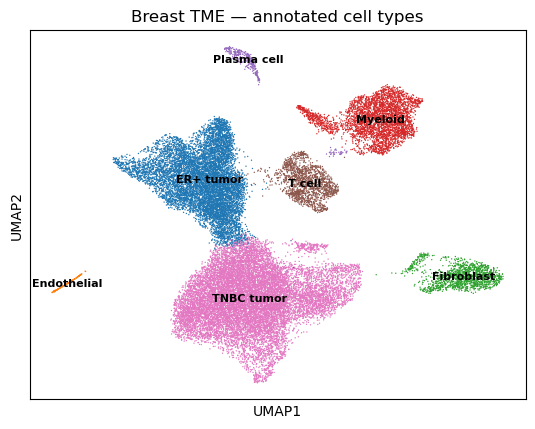

In [6]:
sc.pl.umap(adata, color="cell_type", title="Breast TME — annotated cell types",
           legend_loc="on data", legend_fontsize=8)

In [8]:
# My bulk RNA-seq found ER+ vs TNBC marker differences, but bulk averages all cell types together. 
# My single-cell project confirmed those markers localize specifically to the malignant epithelial compartment — not immune or stromal contamination 
# which validates that the bulk signal was real tumor biology, at single-cell resolution

In [ ]:
# Annotation validation (lightweight, literature-based) 
#
# Cross-checked against independent annotation of the SAME GSE161529 TNBC sample
# (15,870 cells) reported in published work. They identified 7 cell types:
#   epithelial, T cells, fibroblasts, vascular endothelial, macrophages,
#   pericytes, plasma cells.
#
# My pipeline recovered 6 of 7:
#   epithelial  (ER+ & TNBC tumor)   T cells    fibroblasts 
#   endothelial    myeloid/macrophage   plasma cells 
#   NOT separately resolved: pericytes — a vessel-support cell often grouped
#   with stromal/endothelial at res 0.5. This is a clustering-granularity
#   difference, not a misannotation.
#
# Original paper also supports the subtype split:
#   proliferative CD8+ T cells characterize TNBC (not ER+), consistent with
#   the immune infiltrate seen here.
#
# CONCLUSION: cell-type calls concordant with published annotation.
# Confirms the bulk-RNA-seq ER+/TNBC markers (ESR1/GATA3 vs KRT14) localize
# specifically to the epithelial/tumor compartment — bulk signal = real tumor biology.

In [10]:
adata.write("data/processed/03_annotated.h5ad")
import os
print("Saved:", os.path.exists("data/processed/03_annotated.h5ad"), adata.shape)

Saved: True (31265, 2000)
